In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())


Saving TeluguMovies_dataset.csv to TeluguMovies_dataset.csv
Dataset loaded successfully!
Shape: (1400, 9)


,Unnamed: 0,Movie,Year,Certificate,Genre,Overview,Runtime,Rating,No.of.Ratings
0,0,Bahubali: The Beginning,2015.0,UA,"Action, Drama","In ancient India, an adventurous and darin...",159,8.1,99114
1,1,Baahubali 2: The Conclusion,2017.0,UA,"Action, Drama","When Shiva, the son of Bahubali, learns ab...",167,8.2,71458
2,2,1 - Nenokkadine,2014.0,UA,"Action, Thriller",A rock star must overcome his psychologica...,170,8.1,42372
3,3,Dhoom:3,2013.0,UA,"Action, Thriller","When Sahir, a circus entertainer trained i...",172,5.4,42112
4,4,Ra.One,2011.0,U,"Action, Adventure, Sci-Fi",When the titular antagonist of an action g...,156,4.6,37211


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'TeluguMovies_dataset.csv', 'sample_data']


In [ ]:
print("Number of rows and columns:", df.shape)
print("Total movies:", df.shape[0])
print("Total columns:", df.shape[1])


Number of rows and columns: (1400, 9)
Total movies: 1400
Total columns: 9


In [ ]:
print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['Unnamed: 0', 'Movie', 'Year', 'Certificate', 'Genre', 'Overview', 'Runtime', 'Rating', 'No.of.Ratings']


In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1400 non-null   int64  
 1   Movie          1400 non-null   object 
 2   Year           1352 non-null   float64
 3   Certificate    951 non-null    object 
 4   Genre          1389 non-null   object 
 5   Overview       1221 non-null   object 
 6   Runtime        1400 non-null   int64  
 7   Rating         1400 non-null   float64
 8   No.of.Ratings  1400 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 98.6+ KB


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Unnamed: 0         0
Movie              0
Year              48
Certificate      449
Genre             11
Overview         179
Runtime            0
Rating             0
No.of.Ratings      0
dtype: int64


In [ ]:

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_report)


,Missing Values,Missing Percentage
Unnamed: 0,0,0.00
Movie,0,0.00
Year,48,3.43
Certificate,449,32.07
Genre,11,0.79
Overview,179,12.79
Runtime,0,0.00
Rating,0,0.00
No.of.Ratings,0,0.00


In [ ]:

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate movie titles:", df["Movie"].duplicated().sum())


Duplicate rows: 0
Duplicate movie titles: 24


In [ ]:

# Create a copy so the original dataset stays unchanged
clean_df = df.copy()

# Remove the unnecessary index column
clean_df = clean_df.drop(columns=["Unnamed: 0"], errors="ignore")

# Remove completely duplicated rows
clean_df = clean_df.drop_duplicates()

# Fill missing text fields with Unknown
clean_df["Certificate"] = clean_df["Certificate"].fillna("Unknown")

# Remove extra spaces from movie titles
clean_df["Movie"] = clean_df["Movie"].astype(str).str.strip()

# Display the cleaned dataset information
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", clean_df.shape)

print("\nMissing values after cleaning:")
print(clean_df.isnull().sum())

display(clean_df.head())


Original dataset shape: (1400, 9)
Cleaned dataset shape: (1400, 8)

Missing values after cleaning:
Movie              0
Year              48
Certificate        0
Genre             11
Overview         179
Runtime            0
Rating             0
No.of.Ratings      0
dtype: int64


,Movie,Year,Certificate,Genre,Overview,Runtime,Rating,No.of.Ratings
0,Bahubali: The Beginning,2015.0,UA,"Action, Drama","In ancient India, an adventurous and darin...",159,8.1,99114
1,Baahubali 2: The Conclusion,2017.0,UA,"Action, Drama","When Shiva, the son of Bahubali, learns ab...",167,8.2,71458
2,1 - Nenokkadine,2014.0,UA,"Action, Thriller",A rock star must overcome his psychologica...,170,8.1,42372
3,Dhoom:3,2013.0,UA,"Action, Thriller","When Sahir, a circus entertainer trained i...",172,5.4,42112
4,Ra.One,2011.0,U,"Action, Adventure, Sci-Fi",When the titular antagonist of an action g...,156,4.6,37211


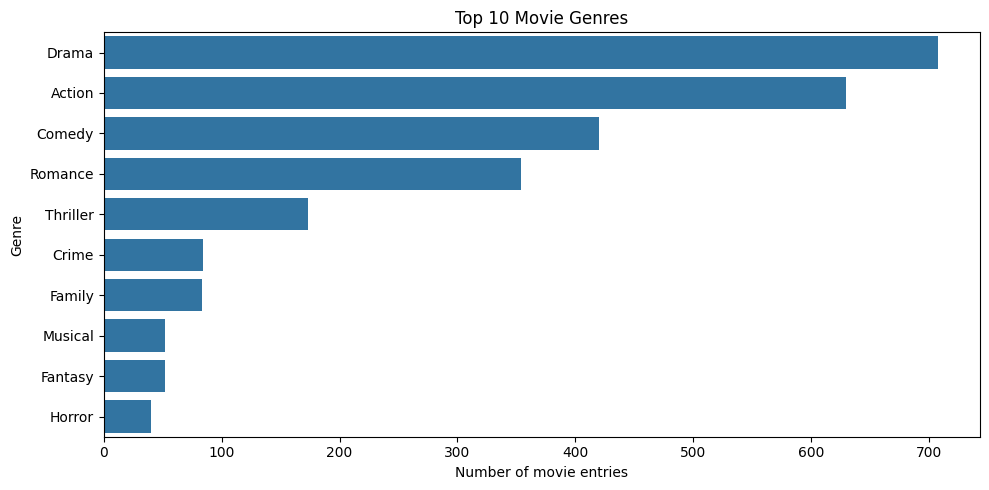

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count movies by genre
genre_counts = (
    clean_df["Genre"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Top 10 Movie Genres")
plt.xlabel("Number of movie entries")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


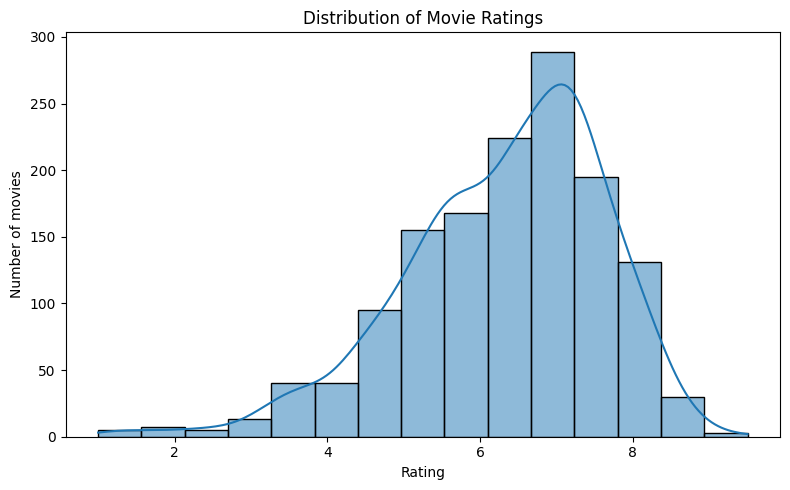

In [ ]:

plt.figure(figsize=(8, 5))
sns.histplot(data=clean_df, x="Rating", bins=15, kde=True)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.show()


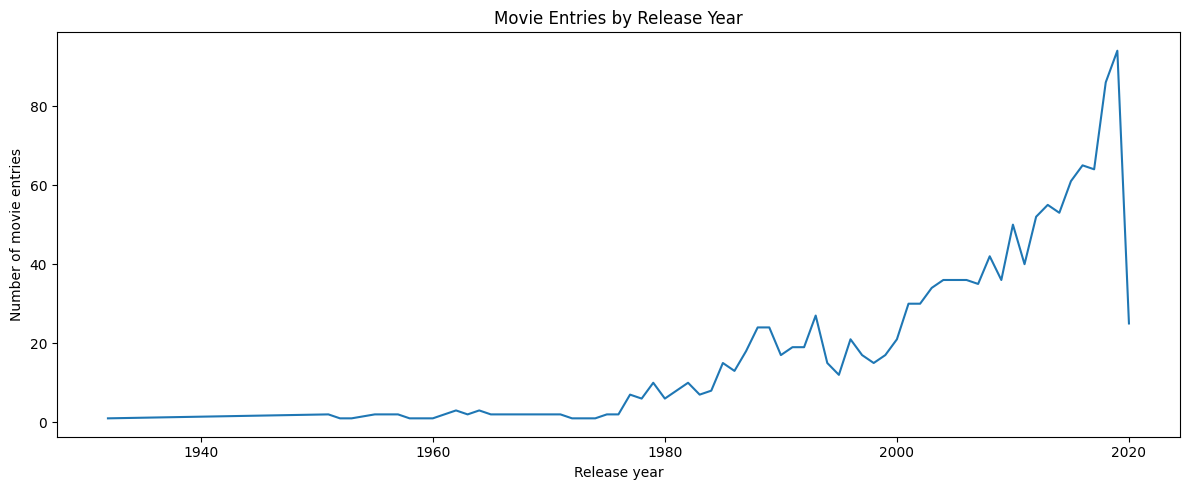

In [ ]:

year_counts = (
    clean_df["Year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values)
plt.title("Movie Entries by Release Year")
plt.xlabel("Release year")
plt.ylabel("Number of movie entries")
plt.tight_layout()
plt.show()


In [ ]:

# Summary statistics for the dataset

print("Average movie rating:")
print(round(clean_df["Rating"].mean(), 2))

print("\nHighest movie rating:")
print(clean_df["Rating"].max())

print("\nLowest movie rating:")
print(clean_df["Rating"].min())

print("\nTop 10 highest-rated movies:")
top_movies = clean_df[
    ["Movie", "Year", "Genre", "Rating", "No.of.Ratings"]
].sort_values(by="Rating", ascending=False).head(10)

display(top_movies)

print("\nMost common genres:")
display(genre_counts.head(10))


Average movie rating:
6.32

Highest movie rating:
9.5

Lowest movie rating:
1.0

Top 10 highest-rated movies:


,Movie,Year,Genre,Rating,No.of.Ratings
429,Pichhodu,2019.0,Drama,9.5,605
92,Maya Bazaar,1957.0,"Comedy, Drama, Family",9.2,3733
96,C/o Kancharapalem,2018.0,Drama,9.0,3699
145,Aha Naa Pellanta,1987.0,Comedy,8.9,2438
1383,Screenplay of an Indian Love Story,2020.0,Drama,8.9,50
261,Gundamma Katha,1962.0,"Comedy, Drama",8.8,1236
468,Daana Veera Soora Karna,1977.0,"Action, Drama, Fantasy",8.8,530
1057,Runam,2019.0,Romance,8.8,91
134,Sagara Sangamam,1983.0,"Musical, Romance, Drama",8.8,2639
103,Nuvvu Naaku Nachchav,2001.0,"Musical, Comedy, Family",8.7,3475



Most common genres:


,count
Genre,
Drama,708
Action,630
Comedy,420
Romance,354
Thriller,173
Crime,84
Family,83
Musical,52
Fantasy,52


In [ ]:

# Top 10 movies by number of ratings
popular_movies = clean_df[
    ["Movie", "Year", "Genre", "Rating", "No.of.Ratings"]
].sort_values(
    by="No.of.Ratings", ascending=False
).head(10)

display(popular_movies)


,Movie,Year,Genre,Rating,No.of.Ratings
0,Bahubali: The Beginning,2015.0,"Action, Drama",8.1,99114
1,Baahubali 2: The Conclusion,2017.0,"Action, Drama",8.2,71458
2,1 - Nenokkadine,2014.0,"Action, Thriller",8.1,42372
3,Dhoom:3,2013.0,"Action, Thriller",5.4,42112
4,Ra.One,2011.0,"Action, Adventure, Sci-Fi",4.6,37211
5,Dhoom:2,2006.0,"Action, Thriller",6.5,22983
6,Eega,2012.0,"Action, Fantasy",7.7,20636
7,Krrish 3,2013.0,"Action, Sci-Fi",5.2,20026
8,Arjun Reddy,2017.0,"Action, Drama, Romance",8.1,19419
9,Rangasthalam,2018.0,"Action, Drama",8.4,17559


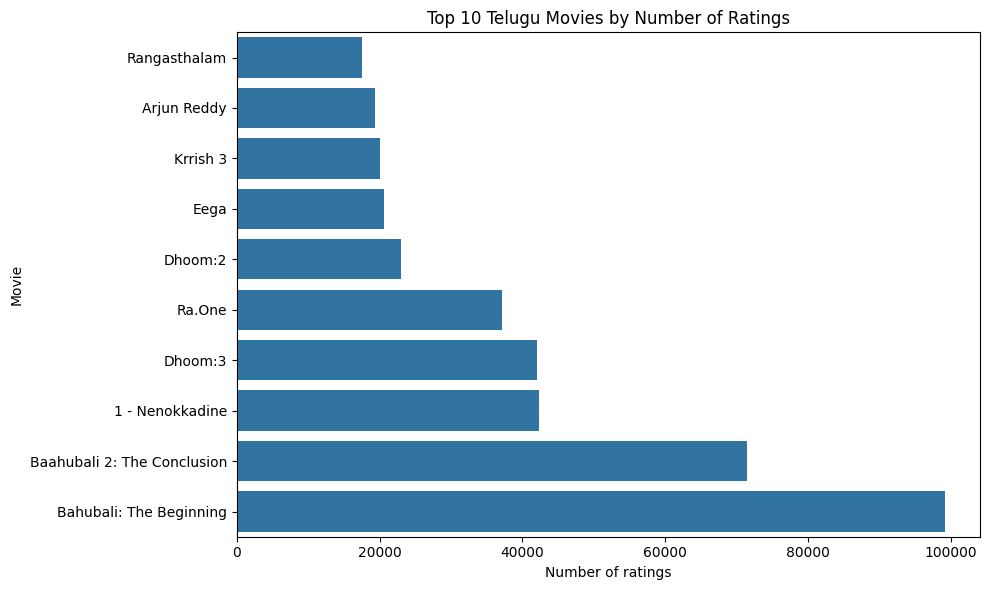

In [ ]:

top_popular = popular_movies.sort_values("No.of.Ratings")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_popular,
    x="No.of.Ratings",
    y="Movie"
)
plt.title("Top 10 Telugu Movies by Number of Ratings")
plt.xlabel("Number of ratings")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()


In [ ]:

# Save the cleaned dataset
clean_df.to_csv("TeluguMovies_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!


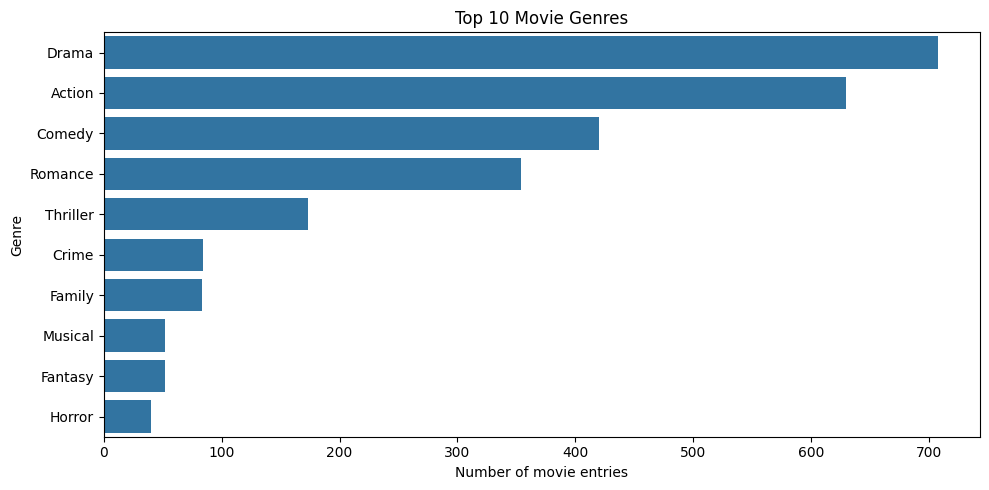

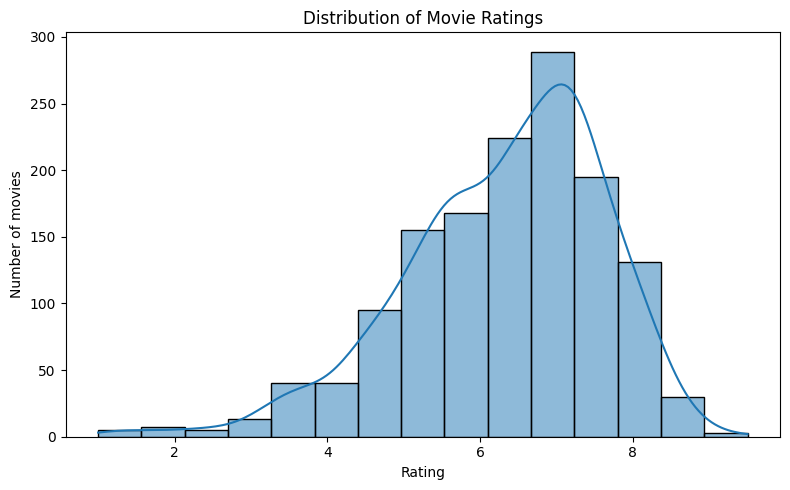

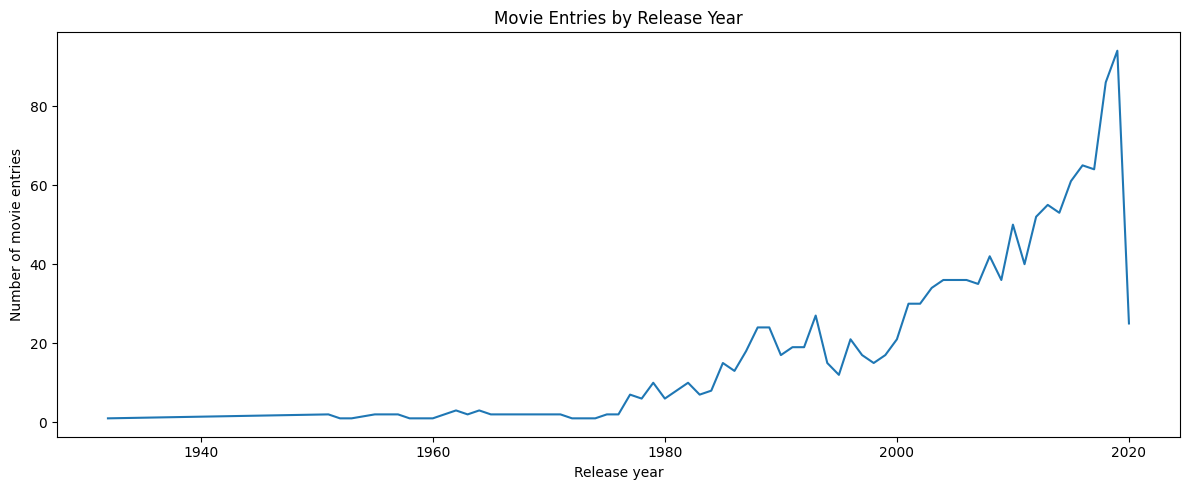

All three graphs saved in the figures folder!


In [ ]:

import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)

# 1. Genre distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Top 10 Movie Genres")
plt.xlabel("Number of movie entries")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("figures/genre_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Rating distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=clean_df, x="Rating", bins=15, kde=True)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.savefig("figures/rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Release year distribution
year_counts = clean_df["Year"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values)
plt.title("Movie Entries by Release Year")
plt.xlabel("Release year")
plt.ylabel("Number of movie entries")
plt.tight_layout()
plt.savefig("figures/release_year_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("All three graphs saved in the figures folder!")


In [ ]:
import shutil
shutil.make_archive("eda_figures", "zip", "figures")
files.download("eda_figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>